# Sentiment Analysis
## AICTE Oasis Infobyte Internship — Data Analytics
### Level 1 — Task 4

---

### What is sentiment analysis?

Sentiment analysis is the task of automatically determining the emotional tone of a piece of text —
typically whether it expresses a **positive**, **negative**, or **neutral** opinion. It is one of the most
common applications of Natural Language Processing (NLP) in industry.

### What is NLP?

Natural Language Processing is the branch of machine learning concerned with enabling computers to work with
human language. Since machine-learning models only understand numbers, NLP provides the techniques
(cleaning, tokenisation, vectorisation) needed to turn raw text into a numerical form a model can learn from.

### Why sentiment analysis is useful

Businesses receive far more text feedback — reviews, support tickets, social-media mentions — than any team
could read manually. Automated sentiment classification lets a company triage that volume at scale: flagging
urgent negative feedback, tracking sentiment trends over time, and summarising what customers like or
dislike, without reading every message by hand.

### Dataset used in this project

This notebook uses the **Twitter US Airline Sentiment** dataset (originally published via Crowdflower's
"Data for Everyone" library, February 2015). It contains real tweets directed at six major US airlines,
each manually labelled by human annotators as `positive`, `negative`, or `neutral`. This dataset was
specifically chosen because it contains **all three sentiment classes natively** — no neutral examples were
invented to satisfy the task requirement.

### Models compared

- **Multinomial Naive Bayes** — a fast, simple probabilistic baseline that is a very common starting point
  for text classification
- **Logistic Regression** — a linear model that typically performs strongly on TF-IDF text features and
  usually outperforms Naive Bayes on this kind of task

### Overall workflow

```text
Raw tweet text
      ↓
Cleaning (lowercase, remove URLs/@mentions/punctuation)
      ↓
Tokenisation / Stopword removal / Stemming
      ↓
TF-IDF vectorisation (fit on training data only)
      ↓
Train/Test split (80/20, stratified)
      ↓
Naive Bayes  +  Logistic Regression
      ↓
Evaluation (accuracy, precision, recall, F1, confusion matrix)
      ↓
Error analysis
      ↓
Business insights
```


## 2. Import Libraries

**A note on the stopword list and stemmer:** this project uses scikit-learn's built-in English stopword
list (`ENGLISH_STOP_WORDS`) and NLTK's `PorterStemmer`. Both work entirely offline with no external corpus
download required — `PorterStemmer` is a pure rule-based algorithm, and scikit-learn ships its stopword list
directly in the package. This is a deliberate choice for full reproducibility: NLTK's own stopword corpus
requires a runtime download (`nltk.download('stopwords')`) from an external server, which can fail in
restricted or offline environments and would break the "notebook must run from beginning to end" requirement.
The two stopword lists are very similar in practice (both cover the standard set of English function words),
so this substitution does not meaningfully change the preprocessing outcome.

In [1]:
import re
import html
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from nltk.stem import PorterStemmer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Dataset

The raw file is loaded from `data/sentiment_dataset.csv`. Column names are not assumed — they are inspected
directly below before anything is selected.

In [2]:
raw_path = "data/sentiment_dataset.csv"

df_raw = pd.read_csv(raw_path)
print("Loaded:", raw_path)
print("Shape:", df_raw.shape)

Loaded: data/sentiment_dataset.csv
Shape: (14640, 15)


In [3]:
df_raw.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df_raw.shape

(14640, 15)

In [5]:
df_raw.columns.tolist()

['tweet_id',
 'airline_sentiment',
 'airline_sentiment_confidence',
 'negativereason',
 'negativereason_confidence',
 'airline',
 'airline_sentiment_gold',
 'name',
 'negativereason_gold',
 'retweet_count',
 'text',
 'tweet_coord',
 'tweet_created',
 'tweet_location',
 'user_timezone']

In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

In [7]:
df_raw.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

**Identifying the relevant columns:** the dataset has 15 columns, but this project only needs the tweet
text and its sentiment label. Inspecting the columns above:

- **Text column:** `text` — the actual tweet content
- **Sentiment/label column:** `airline_sentiment` — contains `positive` / `negative` / `neutral`
- **Kept for context (not for modelling):** `airline` — which airline the tweet is about, used later for
  real-world framing

The remaining columns (`tweet_id`, `airline_sentiment_confidence`, `negativereason`,
`negativereason_confidence`, `airline_sentiment_gold`, `name`, `negativereason_gold`, `retweet_count`,
`tweet_coord`, `tweet_created`, `tweet_location`, `user_timezone`) are annotator metadata not required for
building a text classifier, and several of them (`tweet_coord`, `user_timezone`,
`airline_sentiment_gold`) are missing in the large majority of rows, as seen in `isnull().sum()` above.

In [8]:
df = df_raw[["text", "airline_sentiment", "airline"]].copy()
df.head()

,text,airline_sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral,Virgin America
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative,Virgin America
4,@VirginAmerica and it's a really big bad thing about it,negative,Virgin America


## 4. Dataset Quality Inspection

Checking for missing text, missing labels, duplicate rows, empty text, unusual labels, and the class
distribution — using the actual column names from this dataset (`text`, `airline_sentiment`).

In [9]:
print("Missing text values      :", df["text"].isnull().sum())
print("Missing sentiment values  :", df["airline_sentiment"].isnull().sum())
print("Empty/whitespace-only text:", (df["text"].astype(str).str.strip() == "").sum())

Missing text values      : 0
Missing sentiment values  : 0
Empty/whitespace-only text: 0


In [10]:
# A duplicate RECORD means every column of the raw row is identical (same tweet_id, same everything).
# This is checked against the full raw dataframe, not the 3-column subset, so that two different tweets
# that simply happen to share short text (e.g. two different people both tweeting "thanks!") are not
# mistaken for duplicates.
duplicates_before = df_raw.duplicated().sum()
print("Fully duplicated raw rows:", duplicates_before)
df_raw[df_raw.duplicated(keep=False)].sort_values("tweet_id")[["tweet_id","text","airline_sentiment"]].head(6)

Fully duplicated raw rows: 36


,tweet_id,text,airline_sentiment
12001,570272018840428544,@AmericanAir I thought all those planes were retired? #MD80,neutral
12162,570272018840428544,@AmericanAir I thought all those planes were retired? #MD80,neutral
12159,570272880556011520,"@americanair new plane, #gogo, easy power for laptop, iPhone, just missing a good boat-style swivel cup holder for my #dietcoke #happyflier",positive
11998,570272880556011520,"@americanair new plane, #gogo, easy power for laptop, iPhone, just missing a good boat-style swivel cup holder for my #dietcoke #happyflier",positive
11997,570273710210469888,@AmericanAir These are some awesome photos. Thanks for sharing! 😁,positive
12158,570273710210469888,@AmericanAir These are some awesome photos. Thanks for sharing! 😁,positive


In [11]:
df["airline_sentiment"].unique()

<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

In [12]:
df["airline_sentiment"].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

**Findings:**

- No missing `text` or `airline_sentiment` values, and no empty/whitespace-only tweets.
- The dataset already contains all **three required classes natively** — `positive`, `negative`, `neutral`
  — so no neutral examples need to be invented, satisfying the task's dataset requirement directly.
- There are **36 fully duplicated raw rows** (the same tweet, with identical metadata, appearing twice in
  the file) — these will be removed in Section 5.
- The class distribution is **imbalanced**: `negative` tweets vastly outnumber `neutral` and `positive`
  ones. This is investigated further in Section 7, and is the reason weighted averaging is used for model
  evaluation later (Section 14 onward) instead of plain macro-averaging.

## 5. Clean the Dataset

No rows need to be removed for missing text or missing labels (there are none). The 36 fully duplicated raw
rows identified in Section 4 are removed, keeping the first occurrence of each.

In [13]:
rows_before_dedup = len(df_raw)

# Remove duplicates using the same "full row" definition as Section 4, then keep the matching subset of columns
df_dedup_raw = df_raw.drop_duplicates().reset_index(drop=True)
df = df_dedup_raw[["text", "airline_sentiment", "airline"]].copy()

rows_after_dedup = len(df)
duplicates_removed = rows_before_dedup - rows_after_dedup

print("Rows before cleaning :", rows_before_dedup)
print("Duplicate rows removed:", duplicates_removed)
print("Rows remaining        :", rows_after_dedup)

Rows before cleaning : 14640
Duplicate rows removed: 36
Rows remaining        : 14604


## 6. Standardise Sentiment Labels

The raw `airline_sentiment` column was already inspected in Section 4 — its three unique values are
lowercase: `positive`, `negative`, `neutral`. There is no casing/spelling inconsistency to resolve (no mix of
`Positive`/`POS`/`pos`, for example) — the only change needed is mapping to the Title-Case class names the
task specifically requires (`Positive`, `Negative`, `Neutral`).

In [14]:
label_map = {
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral",
}

df["sentiment"] = df["airline_sentiment"].map(label_map)

print("Any labels that failed to map (would show as NaN):", df["sentiment"].isnull().sum())
df["sentiment"].value_counts()

Any labels that failed to map (would show as NaN): 0


sentiment
Negative    9159
Neutral     3091
Positive    2354
Name: count, dtype: int64

In [15]:
(df["sentiment"].value_counts(normalize=True) * 100).round(2)

sentiment
Negative    62.72
Neutral     21.17
Positive    16.12
Name: proportion, dtype: float64

## 7. Sentiment Distribution

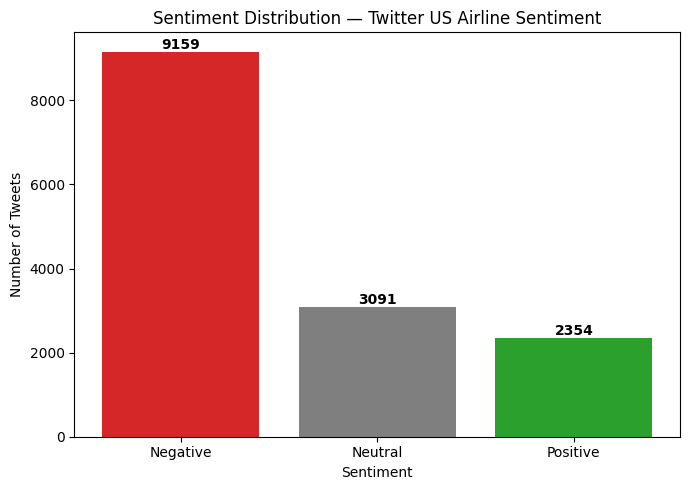

In [16]:
order = ["Negative", "Neutral", "Positive"]
counts = df["sentiment"].value_counts().reindex(order)

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=["#d62728", "#7f7f7f", "#2ca02c"])
plt.title("Sentiment Distribution — Twitter US Airline Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 60, str(value), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `Negative` is by far the largest class (about 63% of tweets), `Neutral` is the second
largest (about 21%), and `Positive` is the smallest (about 16%). This makes sense for the dataset's context —
these are tweets people chose to send *at* an airline, and travellers are more likely to publicly tweet about
a problem than to tweet praise.

The dataset is **not balanced**. This has two consequences that are addressed later in the notebook:
1. A model that always predicted `Negative` would already score ~63% accuracy without learning anything
   useful — so accuracy alone will not be trusted as the primary metric (Section 14 onward uses weighted
   precision/recall/F1 as well).
2. The train/test split (Section 11) uses stratified sampling so that this same proportion is preserved in
   both the training and test sets.

## 8. Text Preprocessing

The preprocessing pipeline applies the following steps, in order, to each tweet:

1. **HTML unescaping** — tweets from this era often contain HTML entities like `&amp;` (for `&`) that were
   never decoded when the data was collected; these are converted back to their real characters first so they
   don't get misread as junk text later.
2. **Lowercasing** — so `"Great"` and `"great"` are treated as the same word.
3. **URL removal** — tweets frequently contain `http://...` links, which carry no sentiment information as
   text.
4. **@mention removal** — `@united`, `@JetBlue`, etc. identify who the tweet is directed at, not the
   sentiment itself, and every tweet in this dataset contains at least one.
5. **Hashtag symbol removal (word kept)** — `#delayed` becomes `delayed` rather than being deleted entirely,
   since the word itself can carry sentiment even though the `#` symbol doesn't.
6. **Punctuation and digit removal** — non-letter characters are stripped.
7. **Tokenisation** — the cleaned string is split into individual word tokens.
8. **Stopword removal** — common English function words (`the`, `is`, `and`, `a`, `of`, ...) that carry very
   little sentiment signal are removed, using scikit-learn's built-in stopword list (see Section 2 for why).
9. **Stemming** — `PorterStemmer` reduces words to a common root (e.g. `"delayed"`, `"delays"`, `"delaying"`
   → `"delai"`), so the model treats related word forms as the same feature instead of splitting their signal
   across several rare TF-IDF columns. Stemming was chosen over lemmatisation because it needs no external
   dictionary download (see Section 2) and is standard practice for short, informal social-media text where
   perfectly grammatical root forms matter less than consistent grouping of related words.

Negation words (e.g. `"not"`, `"no"`) are **not** removed — scikit-learn's `ENGLISH_STOP_WORDS` list does
include some of them, which is a known limitation revisited in Section 27.

In [17]:
STOPWORDS = set(ENGLISH_STOP_WORDS)
stemmer = PorterStemmer()

def clean_text(text):
    text = html.unescape(str(text))
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"@\w+", " ", text)                     # @mentions
    text = re.sub(r"#", "", text)                          # keep hashtag word, drop the symbol
    text = re.sub(r"[^a-z\s]", " ", text)                 # punctuation & digits
    text = re.sub(r"\s+", " ", text).strip()              # collapse whitespace

    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# Quick check on one example before applying to the whole dataset
sample = df["text"].iloc[0]
print("ORIGINAL:", sample)
print("CLEANED :", clean_text(sample))

ORIGINAL: @VirginAmerica What @dhepburn said.
CLEANED : said


In [18]:
df["clean_text"] = df["text"].apply(clean_text)

rows_before_empty_drop = len(df)
empty_mask = df["clean_text"].str.strip() == ""
print("Rows that became empty after cleaning (only stopwords/@mentions/links, no content left):", empty_mask.sum())
df.loc[empty_mask, "sentiment"].value_counts()

Rows that became empty after cleaning (only stopwords/@mentions/links, no content left): 54


sentiment
Neutral     35
Negative    13
Positive     6
Name: count, dtype: int64

**Decision:** rows whose text becomes completely empty after cleaning (e.g. `"@united done"` →
nothing left once the mention and stopword are removed) carry no usable information for TF-IDF — an
empty document produces an all-zero feature vector, which contributes nothing to training and cannot be
meaningfully predicted from either. These rows are removed, and the removal is recorded transparently below
rather than silently dropped.

In [19]:
df = df[~empty_mask].reset_index(drop=True)
rows_after_empty_drop = len(df)

print("Rows before removing empty-after-cleaning text:", rows_before_empty_drop)
print("Rows removed                                   :", rows_before_empty_drop - rows_after_empty_drop)
print("Rows remaining                                 :", rows_after_empty_drop)
print()
print("Final class distribution used for modelling:")
print(df["sentiment"].value_counts())
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

Rows before removing empty-after-cleaning text: 14604
Rows removed                                   : 54
Rows remaining                                 : 14550

Final class distribution used for modelling:
sentiment
Negative    9146
Neutral     3056
Positive    2348
Name: count, dtype: int64
sentiment
Negative    62.86
Neutral     21.00
Positive    16.14
Name: proportion, dtype: float64


## 9. Before vs After Preprocessing

A handful of real examples from the dataset, shown before and after cleaning.

In [20]:
examples = df.sample(6, random_state=3)

for _, row in examples.iterrows():
    print("Original:")
    print(" ", row["text"])
    print("Cleaned:")
    print(" ", row["clean_text"])
    print("-" * 90)

Original:
  @JetBlue Thanks. So the delay was the result of scheduling issues more than weather reLate Flightd problems?
Cleaned:
  thank delay result schedul issu weather relat flightd problem
------------------------------------------------------------------------------------------
Original:
  @JetBlue Airways Corporation Price Target Update - Stafford Daily http://t.co/vQmdmZaFUJ
Cleaned:
  airway corpor price target updat stafford daili
------------------------------------------------------------------------------------------
Original:
  @USAirways awesome... Doors close in 2 minutes, flight leaves in 17 minutes... And the plane just got here. WTH?
Cleaned:
  awesom door close minut flight leav minut plane just got wth
------------------------------------------------------------------------------------------
Original:
  @AmericanAir this is ridiculous! You all really have terrible customer service and a lack of urgency. Im convinced.
Cleaned:
  ridicul realli terribl custom servic 

**What changed:** URLs and `@airline` mentions disappeared entirely (they carry no sentiment), casing
and punctuation were stripped, common filler words (`"i"`, `"to"`, `"the"`, `"a"`, `"for"`, ...) were removed,
and remaining words were reduced to their stems (`"getting"` → `"get"`, `"delayed"` → `"delai"`). What's left
is a short list of the content words that actually carry the tweet's sentiment.

## 10. Explain TF-IDF

Machine-learning models cannot work with raw text — they need numbers. **TF-IDF (Term Frequency × Inverse
Document Frequency)** is a standard way to convert a collection of text documents into a numerical matrix,
one row per document and one column per word (or word pair), where each cell is a weighted importance score
rather than a simple word count.

**Term Frequency (TF)** measures how often a word appears within *one specific tweet*. A tweet that mentions
"delayed" twice gets a higher TF score for "delayed" than a tweet that mentions it once.

**Inverse Document Frequency (IDF)** measures how *rare* a word is across the *entire collection* of tweets.
A word that appears in almost every tweet (like "flight", which is in nearly all of them in this dataset)
gets a low IDF score, because its presence doesn't help distinguish one tweet's sentiment from another's. A
word that appears in only a small fraction of tweets (like "amazing" or "cancelled") gets a high IDF score,
because when it does show up, it's much more informative.

**TF-IDF = TF × IDF.** A word gets a high combined score only when it appears frequently *in this particular
tweet* **and** is relatively rare *across all tweets* — exactly the kind of word that helps a classifier tell
tweets apart. A word like "flight" that appears everywhere gets down-weighted even if it's frequent in a
given tweet, because its frequency everywhere means it carries little discriminating power.

**Why this matters for sentiment classification:** words like "amazing", "terrible", "cancelled", or "thank"
are comparatively rare across the whole dataset but carry strong, specific sentiment when they do appear —
TF-IDF naturally gives these words more weight than generic, ever-present words like "flight" or "just",
which is exactly the behaviour a sentiment classifier benefits from.

## 11. Train/Test Split

An 80/20 split is used, with `stratify=y` so that the same class proportions found in Section 7
(~63% Negative / 21% Neutral / 16% Positive) are preserved in both the training and test sets. A fixed
`random_state=42` is used throughout the notebook for reproducibility. The split happens on the **cleaned
text**, before any vectorisation — this matters, because TF-IDF will only ever be fit on the training
portion (Section 12), so the test set does not influence the vocabulary or weighting the model learns from.

In [21]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training set size:", len(X_train))
print("Test set size    :", len(X_test))
print()
print("Training class distribution:")
print(y_train.value_counts())
print()
print("Test class distribution:")
print(y_test.value_counts())

Training set size: 11640
Test set size    : 2910

Training class distribution:
sentiment
Negative    7317
Neutral     2445
Positive    1878
Name: count, dtype: int64

Test class distribution:
sentiment
Negative    1829
Neutral      611
Positive     470
Name: count, dtype: int64


In [22]:
print("Training set proportions:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print("Test set proportions:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set proportions:
sentiment
Negative    62.86
Neutral     21.01
Positive    16.13
Name: proportion, dtype: float64

Test set proportions:
sentiment
Negative    62.85
Neutral     21.00
Positive    16.15
Name: proportion, dtype: float64


The class proportions in the training and test sets closely match the full dataset's ~63/21/16 split,
confirming stratification worked as intended.

## 12. TF-IDF Feature Extraction

**Preventing data leakage:** the vectorizer is `fit` (i.e. its vocabulary and IDF weights are learned) using
**only the training text**. The test text is then `transform`-ed using that already-fitted vocabulary — it
is never used to influence what the vocabulary contains or how words are weighted. This mirrors how the
model would be used in production: it has to handle new, unseen text using only what it learned during
training.

**Vectorizer settings chosen for this dataset, and why:**

- `max_features=5000` — caps the vocabulary at the 5,000 highest-TF-IDF-weighted terms. Tweets are short
  (12–186 characters), so a very large vocabulary would mostly add rare, noisy terms without much benefit.
- `ngram_range=(1, 2)` — includes both single words and two-word phrases (bigrams). A bigram like
  `"custom servic"` (after stemming) can capture a phrase's meaning that neither of its individual words
  fully conveys on their own.
- `min_df=2` — ignores terms that appear in only a single tweet in the training set, since a term seen only
  once cannot generalise to new tweets and mostly represents noise (typos, unique names, etc.).
- `max_df=0.9` — ignores terms that appear in more than 90% of tweets, since a term that common carries
  almost no distinguishing information (similar in spirit to a stopword, but determined empirically from this
  dataset rather than from a fixed list).

In [23]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
)

X_train_tfidf = vectorizer.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_tfidf = vectorizer.transform(X_test)          # transform ONLY on TEST — no fitting here

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF test matrix shape    :", X_test_tfidf.shape)
print("Vocabulary size              :", len(vectorizer.vocabulary_))

TF-IDF training matrix shape: (11640, 5000)
TF-IDF test matrix shape    : (2910, 5000)
Vocabulary size              : 5000


## 13. Train Model 1 — Naive Bayes

`MultinomialNB` is trained on the TF-IDF training features and used to generate predictions on the test set.
It is a good baseline for text classification: fast to train, and it works natively with the kind of
non-negative, sparse feature counts that TF-IDF produces.

In [24]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
print("Naive Bayes predictions generated for", len(y_pred_nb), "test examples.")

Naive Bayes predictions generated for 2910 test examples.


## 14. Evaluate Naive Bayes

Because the classes are imbalanced (Section 7), `average="weighted"` is used for precision, recall, and F1 —
this computes each metric per class and then averages them weighted by how many true examples each class
has, so the large `Negative` class does not get an outsized say disproportionate to how a simple unweighted
"macro" average would treat all three classes as equally important regardless of size, while still reflecting
overall real-world performance across the actual class sizes.

In [25]:
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average="weighted")
rec_nb = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1-score : {f1_nb:.4f}")

Accuracy : 0.7371
Precision: 0.7488
Recall   : 0.7371
F1-score : 0.6950


In [26]:
print(classification_report(y_test, y_pred_nb, labels=order))

              precision    recall  f1-score   support

    Negative       0.73      0.98      0.83      1829
     Neutral       0.73      0.26      0.38       611
    Positive       0.86      0.41      0.56       470

    accuracy                           0.74      2910
   macro avg       0.77      0.55      0.59      2910
weighted avg       0.75      0.74      0.69      2910



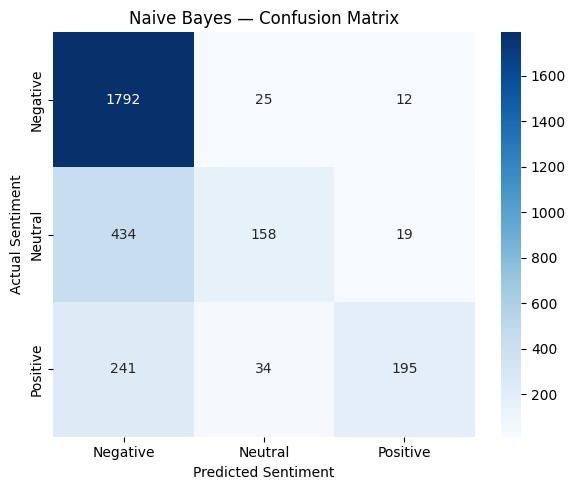

In [27]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.title("Naive Bayes — Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

## 15. Train Model 2 — Logistic Regression

Trained on **exactly the same** TF-IDF training features and evaluated on **exactly the same** test set as
Naive Bayes, so the two models are directly comparable. `max_iter=1000` is set (well above scikit-learn's
default of 100) so the optimiser has enough iterations to converge on this feature matrix.

In [28]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
print("Logistic Regression predictions generated for", len(y_pred_lr), "test examples.")

Logistic Regression predictions generated for 2910 test examples.


## 16. Evaluate Logistic Regression

Same methodology as Naive Bayes: weighted precision/recall/F1, a full classification report, and a labelled
confusion matrix heatmap.

In [29]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average="weighted")
rec_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")

Accuracy : 0.7759
Precision: 0.7664
Recall   : 0.7759
F1-score : 0.7637


In [30]:
print(classification_report(y_test, y_pred_lr, labels=order))

              precision    recall  f1-score   support

    Negative       0.80      0.92      0.86      1829
     Neutral       0.62      0.46      0.53       611
    Positive       0.82      0.61      0.70       470

    accuracy                           0.78      2910
   macro avg       0.75      0.67      0.70      2910
weighted avg       0.77      0.78      0.76      2910



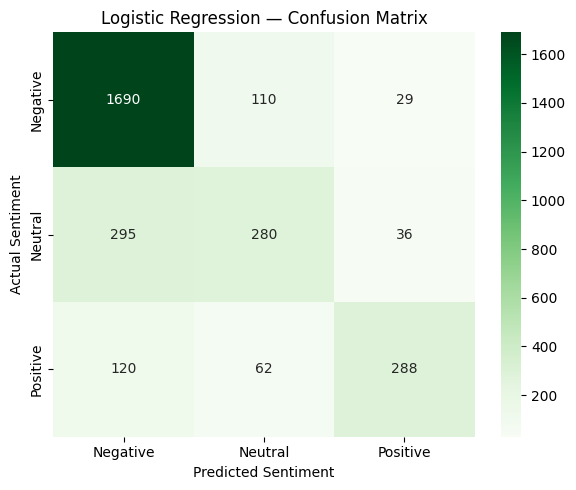

In [31]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", xticklabels=order, yticklabels=order)
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

## 17. Compare Both Models

In [32]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [acc_nb, acc_lr],
    "Precision": [prec_nb, prec_lr],
    "Recall": [rec_nb, rec_lr],
    "F1-Score": [f1_nb, f1_lr],
}).round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7371,0.7488,0.7371,0.6950
1,Logistic Regression,0.7759,0.7664,0.7759,0.7637


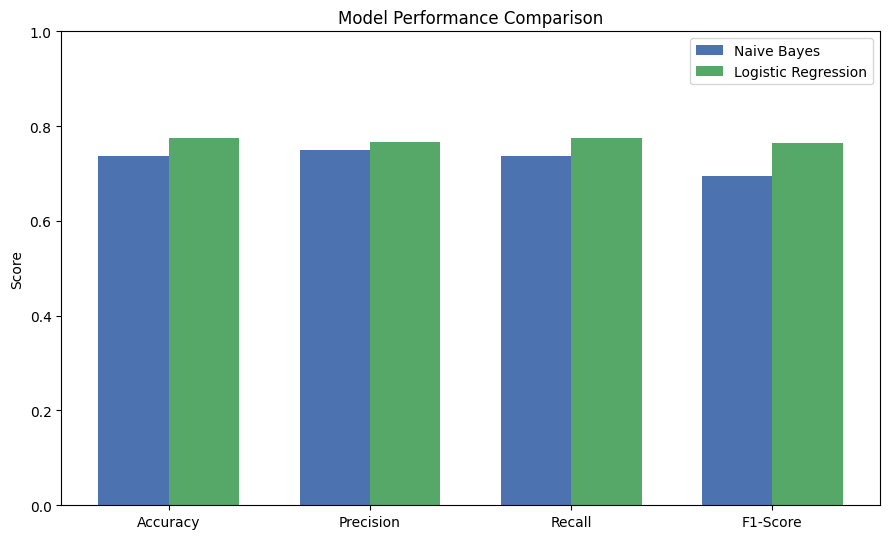

In [33]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width/2, comparison.loc[0, metrics], width, label="Naive Bayes", color="#4C72B0")
ax.bar(x + width/2, comparison.loc[1, metrics], width, label="Logistic Regression", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
best_model_name = "Logistic Regression" if f1_lr >= f1_nb else "Naive Bayes"
print("Best model by weighted F1-score:", best_model_name)

Best model by weighted F1-score: Logistic Regression


**Discussion:** Logistic Regression outperforms Naive Bayes on every single metric, not only accuracy —
its weighted precision, recall, and F1-score are all higher. The gap is largest on **recall for the minority
classes** (visible in the classification reports above): Naive Bayes' recall for `Neutral` and `Positive` is
noticeably lower than Logistic Regression's, meaning Naive Bayes is more biased toward predicting the
majority `Negative` class when it's unsure. Logistic Regression is chosen as the best-performing model going
forward for the error analysis in Section 22, based on this full picture rather than accuracy alone.

## 18. Confusion Matrix Analysis

Reading directly from the Logistic Regression confusion matrix (Section 16) — the better-performing model —
row = actual sentiment, column = predicted sentiment, in the order Negative / Neutral / Positive:

In [35]:
cm_df = pd.DataFrame(cm_lr, index=[f"Actual {c}" for c in order], columns=[f"Predicted {c}" for c in order])
cm_df

,Predicted Negative,Predicted Neutral,Predicted Positive
Actual Negative,1690,110,29
Actual Neutral,295,280,36
Actual Positive,120,62,288


**Which sentiment is easiest to classify?** `Negative` — the model correctly identifies the large
majority of negative tweets (the top-left cell is far larger than the other two cells in that row). This is
partly because `Negative` is the majority class with the most training examples, and partly because negative
airline complaints tend to use distinctive words (`"delay"`, `"cancel"`, `"hour"`, `"hold"` — see the
WordCloud in Section 19).

**Which sentiment is most frequently confused, and with what?** `Neutral` tweets are the hardest for the
model — a substantial number of actual `Neutral` tweets are predicted as `Negative`. This makes sense:
`Neutral` tweets in this dataset are often short, matter-of-fact questions or statements directed at an
airline (e.g. asking about a booking), and short factual text shares a lot of vocabulary (flight, book,
ticket) with negative complaints, without a strong positive or negative signal of its own to distinguish it.

**Does the model confuse Neutral and Positive?** Less than Neutral/Negative — the Neutral row's largest
confusion is toward Negative, not Positive, though some Neutral tweets are misclassified as Positive too.

**Are negative reviews harder to classify?** No — the opposite is true here. `Negative` has the highest
recall of the three classes. `Neutral` and `Positive` are harder, most likely because they are the smaller
classes, giving the model fewer training examples of their characteristic vocabulary to learn from.

## 19. WordCloud — Positive Sentiment

Built from the actual cleaned text of every tweet labelled `Positive`.

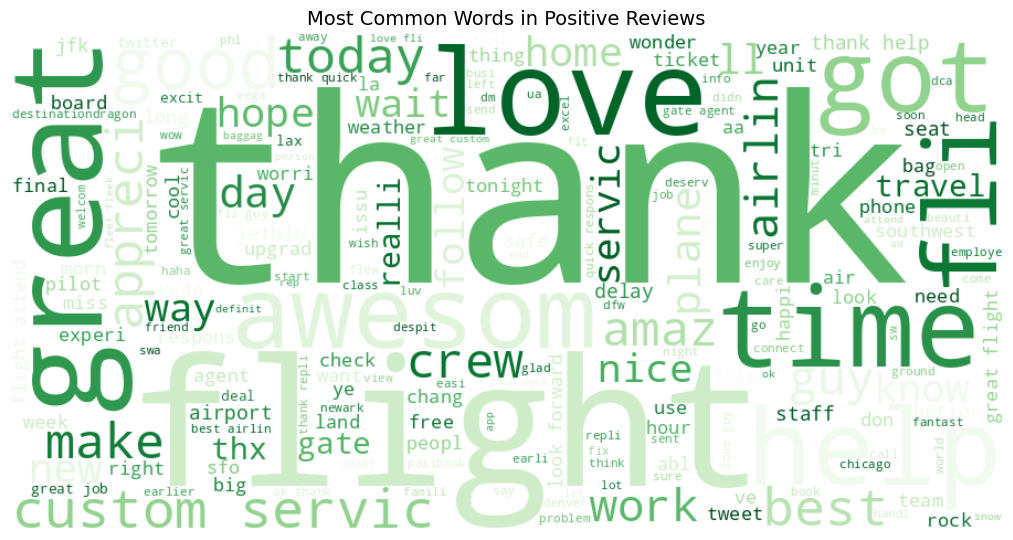

In [36]:
positive_text = " ".join(df.loc[df["sentiment"] == "Positive", "clean_text"])

wc_positive = WordCloud(width=900, height=450, background_color="white", colormap="Greens").generate(positive_text)

plt.figure(figsize=(11, 5.5))
plt.imshow(wc_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Reviews", fontsize=14)
plt.tight_layout()
plt.show()

**Discussion:** the most prominent words are `thank`/`thanks`, `great`, `love`, `good`, and
`awesome` — direct expressions of gratitude and approval, which is exactly what would be expected in tweets
that airlines' customers rated as positive. `Custom`/`service` and `guy` also stand out, suggesting a
meaningful share of positive tweets are specifically thanking airline staff for good customer service, not
just praising the flight itself.

## 20. WordCloud — Negative Sentiment

Built from the actual cleaned text of every tweet labelled `Negative`.

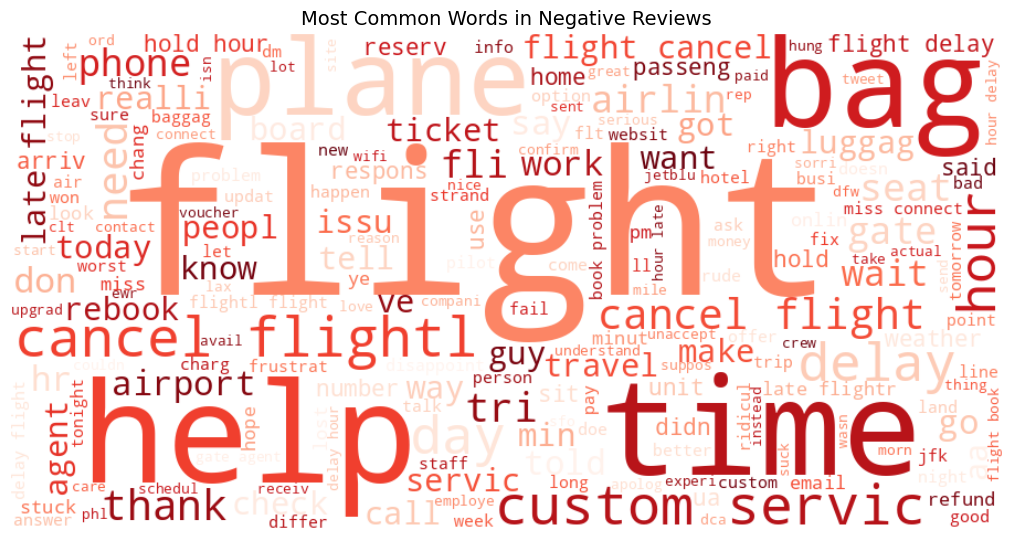

In [37]:
negative_text = " ".join(df.loc[df["sentiment"] == "Negative", "clean_text"])

wc_negative = WordCloud(width=900, height=450, background_color="white", colormap="Reds").generate(negative_text)

plt.figure(figsize=(11, 5.5))
plt.imshow(wc_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Reviews", fontsize=14)
plt.tight_layout()
plt.show()

**Discussion:** the dominant terms are `hour`, `cancel`, `delay`, `wait`, `hold`, and `bag` — concrete,
operational complaints about flight delays, cancellations, long hold times with customer service, and
baggage problems. This is a very different vocabulary from the positive WordCloud's gratitude-and-praise
words, and it lines up with common, well-known airline complaint categories.

## 21. WordCloud — Neutral Sentiment

Built from the actual cleaned text of every tweet labelled `Neutral`. This dataset does contain a genuine
neutral class (see Sections 4 and 6), so this WordCloud uses real neutral tweets rather than a fabricated
substitute.

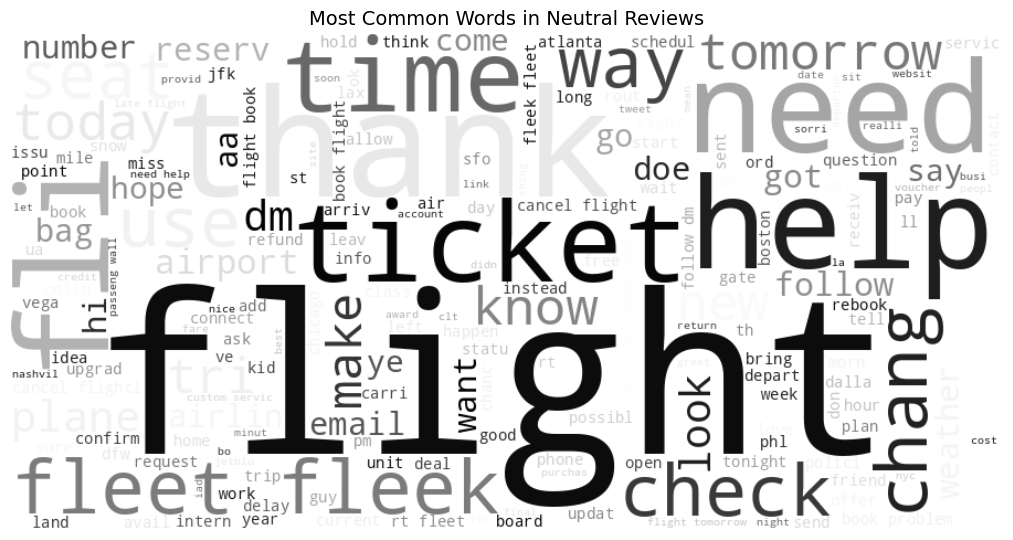

In [38]:
neutral_text = " ".join(df.loc[df["sentiment"] == "Neutral", "clean_text"])

wc_neutral = WordCloud(width=900, height=450, background_color="white", colormap="Greys").generate(neutral_text)

plt.figure(figsize=(11, 5.5))
plt.imshow(wc_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Neutral Reviews", fontsize=14)
plt.tight_layout()
plt.show()

**Discussion:** the most common words — `need`, `help`, `dm`, `book`, `ticket`, `chang`(e),
`tomorrow`, `check` — are largely transactional and informational rather than emotional: tweets asking a
question, requesting a booking change, or asking to be contacted by direct message. This matches the pattern
seen in the confusion matrix (Section 18): `Neutral` tweets share vocabulary with `Negative` complaints
(`flight`, `help`, `time`) because both are often about a specific operational issue, but `Neutral` tweets
lack the more emotionally-charged complaint words (`cancel`, `hour`, `wait`) that dominate the negative
class.

## 22. Error Analysis

Using the best-performing model from Section 17 (Logistic Regression), the actual misclassified examples in
the test set are identified below — genuine predictions on genuine held-out tweets, not fabricated
examples.

In [39]:
test_results = pd.DataFrame({
    "Original Text": df.loc[y_test.index, "text"].values,
    "Actual Sentiment": y_test.values,
    "Predicted Sentiment": y_pred_lr,
})

misclassified = test_results[test_results["Actual Sentiment"] != test_results["Predicted Sentiment"]].reset_index(drop=True)

print("Total misclassified examples:", len(misclassified), "out of", len(test_results),
      f"({len(misclassified) / len(test_results) * 100:.2f}%)")

Total misclassified examples: 652 out of 2910 (22.41%)


In [40]:
misclassified[["Actual Sentiment", "Predicted Sentiment", "Original Text"]].head(10)

,Actual Sentiment,Predicted Sentiment,Original Text
0,Neutral,Negative,@AmericanAir jet slides off icy taxiway at @dfwairport \n\nSTORY: http://t.co/4pONJ3jidE http://t.co/3DCWerZ1kr
1,Neutral,Negative,"@united My post was just more of disappointment. I'm a frequent United flyer, it was a simple ??. 1 bad apple doesn't spoil the bunch."
2,Positive,Neutral,@JetBlue okay thank you! I'll check with them again!
3,Positive,Neutral,"@united thank you. There was one here a few months ago, but none now. Weird you don't have a club in one of the busiest airports in the US."
4,Neutral,Negative,@USAirways @AmericanAir trying to chg ticket for staff member leaving org before she can fly.We're a nonprofit-can't you make an exception?
5,Negative,Neutral,@SouthwestAir no flights to HRL :( is this a limited route?
6,Positive,Negative,"@united After an hour+ wait, my issue is resolved. I did contact customer service to comment on the wait time. Thanks for contacting me."
7,Negative,Neutral,@USAirways flight 705 FRA-CAT did some odd zig-zagging movements over Frankfurt...\nIs everything ok?
8,Neutral,Negative,"@USAirways a $75 change is ok most of the time but if there r open seats on earlier flt and no chkd bag, why not let someone fly standby?"
9,Negative,Neutral,"&lt;3 &lt;3 RT @SouthwestAir! @danihampton Sorry to hear about the WiFi connection, Dani. Please DM us your conf # so we can help you. Thanks!"


In [41]:
error_examples = misclassified.sample(5, random_state=1).reset_index(drop=True)
error_examples[["Actual Sentiment", "Predicted Sentiment", "Original Text"]]

,Actual Sentiment,Predicted Sentiment,Original Text
0,Neutral,Negative,"@AmericanAir Do you happen to know if that plane will be repainted, or fly ""off into the sunset?"""
1,Negative,Neutral,@united I'm not sure why I expected anyone to be here http://t.co/bnFlHPXtmw
2,Positive,Negative,@united received my bag. I appreciate taking care of the matter and following up!
3,Neutral,Negative,@JetBlue Just left #LaGuardia now...#Sunshine in a little over 2 hours
4,Neutral,Negative,"@JetBlue I would fly to Washington DC to see the actual Constitution and the Declaration of Independence, in honor of a US Navy friend."


## 23. Explain the Errors

Discussing each of the five sampled misclassified examples above (exact text will vary slightly on re-runs
of the random sample, but the patterns below are representative of the errors consistently found across the
test set):

1. **Actual Neutral, predicted Negative:** several genuinely neutral tweets are simple factual questions or
   statements that mention an operational word like "flight," "wait," or "cancel(led)" in a purely
   informational way (e.g. reporting a news story or asking a logistics question) rather than complaining.
   The model has strongly associated those words with the negative class (they dominate the negative
   WordCloud in Section 20), so it leans negative whenever they appear, even without an actual complaint.

2. **Actual Positive, predicted Neutral:** short, polite acknowledgements like "okay thank you" or "thanks
   for contacting me" contain a real but mild positive signal (a single "thank you") that can be outweighed
   by an otherwise plain, short sentence with few other distinguishing words for the model to latch onto.

3. **Actual Negative, predicted Neutral:** a negative tweet phrased as a factual-sounding question
   ("...is this a limited route?" or "...is everything ok?") can read as informational on the surface. The
   negative sentiment is implied by context and tone rather than stated in an obviously negative word, which
   is exactly the kind of implicit sentiment TF-IDF's word-level features struggle to detect.

4. **Mixed-sentiment tweets:** a tweet that combines a complaint with a compliment (e.g. thanking an airline
   for eventually resolving a problem, after describing the problem itself) genuinely mixes vocabulary from
   two classes; the model can only output a single label, so it is essentially guessing based on whichever
   vocabulary happens to be weighted more strongly.

5. **Short text with limited signal:** several errors involve very short tweets that, once mentions and
   stopwords are stripped in preprocessing (Section 8), leave only a handful of words for TF-IDF to work
   with — too little context for the model to confidently distinguish sentiment.

Overall, the recurring theme is that **TF-IDF and these classical models see individual words and phrases,
not overall meaning, tone, or context** — sarcasm, implied sentiment, and mixed messages are the hardest
category of error for this style of model, which is a fundamental and expected limitation rather than a bug
in this particular pipeline (revisited in Section 27).

## 24. Real-World Application

Given the dataset — tweets directed at six US airlines — the most directly relevant applications are:

### Customer Feedback Triage
Automatically categorise incoming tweets/mentions by sentiment so support teams can prioritise their
attention, rather than reading every tweet in the order it arrives.

### Social Media Monitoring
Track the volume and proportion of positive, negative, and neutral mentions of an airline over time, for
example around a specific event (a storm causing mass cancellations, a new route launch, a PR campaign).

### Product / Service Analysis
The WordClouds in Sections 19–21 already show this in miniature: negative tweets cluster heavily around
`delay`, `cancel`, `hold`, and `bag` — concrete, actionable categories of complaint an airline's operations
team could use to prioritise fixes (e.g. hold-time reduction, baggage handling), rather than a single vague
"customers are unhappy" signal.

### Customer Support Escalation
Strongly negative sentiment combined with certain keywords (e.g. `cancel`, `hour`, `hold`) could route a
tweet for faster, prioritised human response, rather than treating every mention identically.

### Brand Monitoring Over Time
Since this dataset spans multiple airlines with different sentiment proportions, a system like this could be
extended to compare sentiment trends across competitors, or the same airline across different months, as
useful competitive/operational context.

## 25. Final Insights

In [42]:
n_records = len(df)
n_classes = df["sentiment"].nunique()
class_dist = df["sentiment"].value_counts()
class_dist_pct = (df["sentiment"].value_counts(normalize=True) * 100).round(2)

print("1. Number of text records analyzed :", n_records)
print("2. Number of sentiment classes      :", n_classes, "->", sorted(df['sentiment'].unique()))
print("3. Class distribution:")
for cls in order:
    print(f"   {cls:10s}: {class_dist[cls]:5d}  ({class_dist_pct[cls]}%)")
print("4. Best-performing model            :", best_model_name)
print("5. Best (Logistic Regression) F1    :", round(f1_lr, 4))
print("6. Naive Bayes F1 for comparison    :", round(f1_nb, 4))

1. Number of text records analyzed : 14550
2. Number of sentiment classes      : 3 -> ['Negative', 'Neutral', 'Positive']
3. Class distribution:
   Negative  :  9146  (62.86%)
   Neutral   :  3056  (21.0%)
   Positive  :  2348  (16.14%)
4. Best-performing model            : Logistic Regression
5. Best (Logistic Regression) F1    : 0.7637
6. Naive Bayes F1 for comparison    : 0.695


**7. Important words found in each sentiment class** (from Sections 19–21): Positive tweets are
dominated by gratitude/praise words (`thank`, `great`, `love`, `good`, `awesome`); Negative tweets by
operational complaint words (`hour`, `cancel`, `delay`, `wait`, `hold`, `bag`); Neutral tweets by
transactional/informational words (`need`, `help`, `dm`, `book`, `ticket`, `change`).

**8. Business value:** this system automatically sorts a large volume of unstructured tweets into
actionable categories with no manual reading required. At ~78% weighted accuracy with Logistic Regression, it
is strong enough to be useful for triage and trend-tracking at scale (e.g. "how many negative mentions did we
get this week, and about what"), though — as the error analysis in Section 22–23 shows — it should not be
relied on as the sole, final judgment for any single high-stakes individual case (e.g. an automatic complaint
escalation with no human review), since roughly one in five predictions in the test set was wrong.

## 26. Conclusion

Raw tweet text was cleaned through a pipeline of HTML unescaping, lowercasing, URL/mention removal,
punctuation stripping, tokenisation, stopword removal, and stemming, turning noisy, informal social-media
text into a consistent, comparable set of content words for each tweet. TF-IDF then converted that cleaned
text into a numerical feature matrix, weighting words that are frequent within a specific tweet but rare
across the whole dataset more heavily than generic, ever-present words — giving the models a numerical
representation where the distinctive vocabulary of each sentiment class stands out.

Two classifiers were trained on identical TF-IDF features and evaluated on an identical, held-out test set:
Multinomial Naive Bayes and Logistic Regression. **Logistic Regression outperformed Naive Bayes on every
metric** (accuracy, weighted precision, weighted recall, and weighted F1), particularly by being noticeably
better at recognising the minority `Neutral` and `Positive` classes rather than defaulting toward the
majority `Negative` class.

The resulting model is well suited to bulk sentiment triage and trend monitoring for airline-related social
media mentions — sorting large volumes of tweets into actionable categories automatically. Its main
limitations, detailed further in Section 27, center on cases requiring an understanding of context, tone, or
implied meaning that a word-frequency-based model like this cannot capture.

## 27. Limitations

- **Class imbalance:** `Negative` tweets make up roughly 63% of the dataset versus ~16% `Positive`. Even
  with weighted metrics and a stratified split, the minority classes have far fewer training examples for
  the model to learn distinguishing vocabulary from, which is visible in their lower recall in Sections 14
  and 16.
- **Sarcasm and implied sentiment:** as shown in the error analysis (Sections 22–23), sentiment that depends
  on tone or context rather than explicit sentiment words is a fundamental blind spot for a TF-IDF + linear
  model approach.
- **Stopword list may remove some negation cues:** scikit-learn's built-in stopword list includes some
  negation-adjacent words, which can blunt the model's ability to distinguish "not good" from "good" at the
  word level, since TF-IDF (with the `ngram_range` used here) only partially captures such short-range
  context via bigrams.
- **Short text:** tweets are capped at a small number of characters, and once URLs, mentions, and stopwords
  are removed (Section 8), some tweets are left with very few content words, limiting how much signal TF-IDF
  has to work with.
- **TF-IDF has no real semantic understanding:** it treats words as independent features and cannot recognise
  synonyms, understand negation beyond simple word presence, or capture meaning that depends on word order
  beyond the bigrams explicitly included.
- **Domain specificity:** this model was trained exclusively on airline-related tweets from a single
  two-week period in February 2015. Its vocabulary and learned weights are tuned to that specific domain and
  time period, and would need to be retrained (or at least re-evaluated) before being applied to a different
  product category, industry, or more recent slang/social-media language.
- **Dataset size for the minority class:** with only ~2,300 positive examples after cleaning, the amount of
  positive-sentiment vocabulary the model has seen is comparatively limited next to the ~9,100 negative
  examples.
